# Proyecto: Selección de Ubicación para Nuevos Pozos Petrolíferos (OilyGiant)

## Descripción del Proyecto
Trabajamos para la compañía de extracción de petróleo **OilyGiant**. Nuestra tarea principal es encontrar los mejores lugares para abrir 200 pozos nuevos de petróleo, evaluando tres regiones geológicas distintas.

## Objetivos
1. **Predecir el volumen de reservas**: Construiremos un modelo de Machine Learning (Regresión Lineal) para predecir el volumen de reservas en nuevos pozos basándonos en datos geológicos.
2. **Calcular la ganancia potencial**: Seleccionaremos los 200 pozos con los valores estimados más altos en cada región para maximizar el margen de beneficio.
3. **Evaluación de riesgos**: Utilizaremos la técnica estadística de *Bootstrapping* (remuestreo) para analizar la distribución del beneficio esperado y el riesgo financiero asociado. 

**Condición de negocio crucial:** Solo se considerarán aquellas regiones donde el riesgo de pérdida sea inferior al **2.5%**.

---
## Tabla de Contenidos
1. [Carga y limpieza de datos](#Carga-y-limpieza-de-datos)
2. [Caracterización de los datos](#Caracterización-de-los-datos)
3. [Análisis Exploratorio de Datos (EDA)](#Análisis-Exploratorio-de-Datos-(EDA))
4. [Distribución de Ganancias (Bootstrapping)](#Distribución-de-Ganancias-(Bootstrapping))
5. [Conclusiones generales del proyecto](#Conclusiones-generales-del-proyecto)

### Carga y limpieza de datos
Se procedió a cargar los datos tomando en cuenta la naturaleza de cada columna.
Se evaluó la duplicidad total de cada fila y la duplicidad de la columna identificadora para hacer una depuración y eliminación de información duplicada.
Se depuró tomando en cuenta la posibilidad de que la columna 'product' tuviera elementos menores a 0.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

try:
    data_0 = pd.read_csv('../datasets/geo_data_0.csv')
    data_1 = pd.read_csv('../datasets/geo_data_1.csv')
    data_2 = pd.read_csv('../datasets/geo_data_2.csv')
    
    datasets = [data_0, data_1, data_2]
    regions = ['Región 0', 'Región 1', 'Región 2']
    
    print(" Auditoría y Limpieza Avanzada de Datos ")
    
    for i, df in enumerate(datasets):
        print(f">> Procesando {regions[i]}...")
        initial_shape = df.shape[0]
        
        # Manejo de IDs duplicados (antes de borrar la columna id)
        id_duplicates = df['id'].duplicated().sum()
        if id_duplicates > 0:
            df = df.drop_duplicates(subset='id', keep='first')
            print(f"- IDs duplicados eliminados: {id_duplicates}")
        
        # Evaluación de Valores Nulos
        null_count = df.isnull().sum().sum()
        if null_count > 0:
            df = df.dropna()
            print(f"- Valores nulos eliminados: {null_count}")

        # Product > 0 (evalúa si la volumetría da un valor coherente para calcular)
        # Esto asegura que no evaluemos pozos sin reservas o con errores de registro
        invalid_product = df[df['product'] < 0].shape[0]
        if invalid_product > 0:
            df = df[df['product'] > 0]
            print(f"- Registros con 'product' < 0 eliminados: {invalid_product}")
            
        
        # Guardar el dataset limpio de vuelta en la lista
        datasets[i] = df.reset_index(drop=True)
        
        final_shape = df.shape[0]
        print(f"-> Limpieza finalizada. Filas eliminadas: {initial_shape - final_shape}")
        print(f"-> Tamaño actual: {df.shape}")

    # Actualizamos nuestras variables finales
    data_0, data_1, data_2 = datasets

except FileNotFoundError:
    print("Error: No se encontraron los archivos. Verifica la ruta.")

print("Datos limpios y listos")


 Auditoría y Limpieza Avanzada de Datos 
>> Procesando Región 0...
- IDs duplicados eliminados: 10
-> Limpieza finalizada. Filas eliminadas: 10
-> Tamaño actual: (99990, 5)
>> Procesando Región 1...
- IDs duplicados eliminados: 4
-> Limpieza finalizada. Filas eliminadas: 4
-> Tamaño actual: (99996, 5)
>> Procesando Región 2...
- IDs duplicados eliminados: 4
-> Limpieza finalizada. Filas eliminadas: 4
-> Tamaño actual: (99996, 5)
Datos limpios y listos


In [2]:
data_0.info()
data_1.info()
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99990 entries, 0 to 99989
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       99990 non-null  object 
 1   f0       99990 non-null  float64
 2   f1       99990 non-null  float64
 3   f2       99990 non-null  float64
 4   product  99990 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99996 entries, 0 to 99995
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       99996 non-null  object 
 1   f0       99996 non-null  float64
 2   f1       99996 non-null  float64
 3   f2       99996 non-null  float64
 4   product  99996 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99996 entries, 0 to 99995
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
--

### Caracterización de los datos
Posterior a la limpieza de los datos se obtienen los 3 datasets que se usarán para el proceso.
Los 3 datasets poseen:
5 columnas: 4 con variables tipo float y una con variable tipo object que nos sirve para identificar cada localidad.

En la limpieza solo se descartaron 10 valores del data_0 y 4 valores de los data_1 y data_2.


### Análisis Exploratorio de Datos (EDA)
Para entender mejor la relación entre las características geológicas y el volumen de reservas, visualizaremos las matrices de correlación y las distribuciones de la variable objetivo (`product`) para cada región.

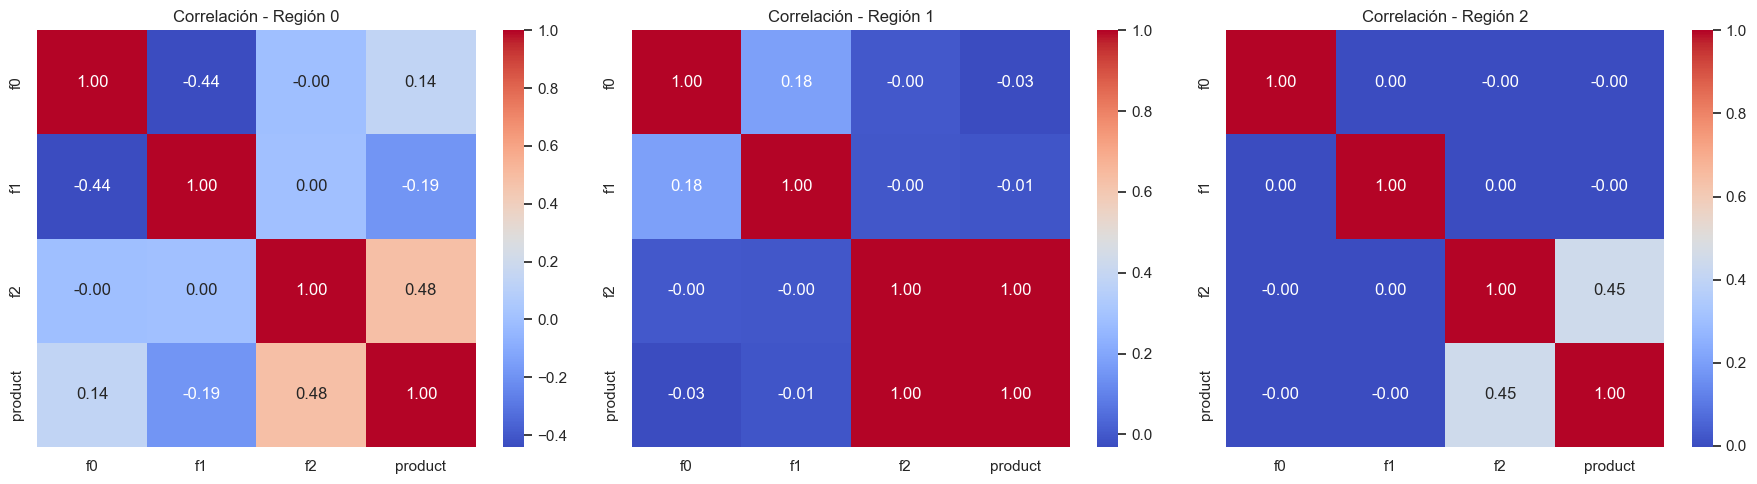

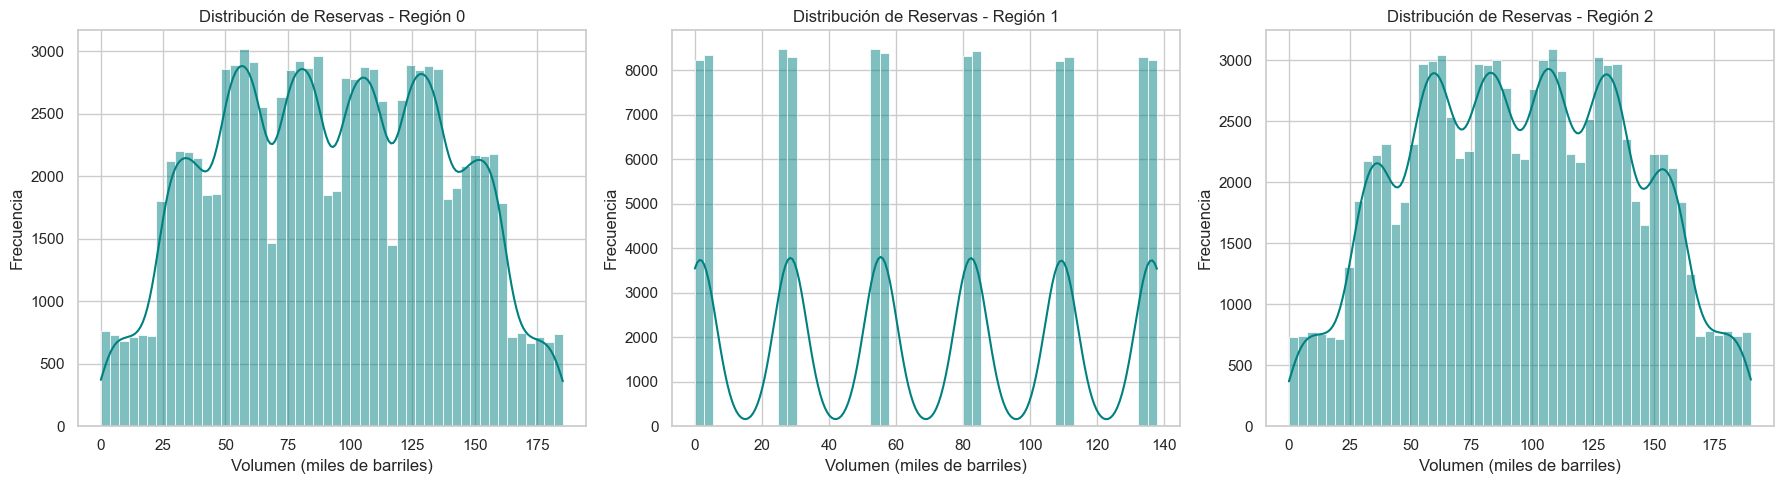

In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid")

# 1. Matrices de Correlación
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
regions_df = [data_0, data_1, data_2]
region_titles = ['Región 0', 'Región 1', 'Región 2']

for i, df in enumerate(regions_df):
    sns.heatmap(df[['f0', 'f1', 'f2', 'product']].corr(), annot=True, cmap='coolwarm', ax=axes[i], fmt=".2f")
    axes[i].set_title(f'Correlación - {region_titles[i]}')

plt.tight_layout()
plt.show()

# 2. Distribución del Volumen de Reservas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, df in enumerate(regions_df):
    sns.histplot(df['product'], bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de Reservas - {region_titles[i]}')
    axes[i].set_xlabel('Volumen (miles de barriles)')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


**Observaciones del EDA:**
- **Correlación:** En la **Región 1**, la característica `f2` tiene una correlación perfecta (1.00) con el volumen de reservas (`product`). Esto sugiere fuertemente que un modelo de regresión lineal será extremadamente preciso en esta región particular.
- **Distribución:** Las regiones 0 y 2 tienen distribuciones de reservas similares, en forma de campana con múltiples picos. Sin embargo, la Región 1 presenta una distribución muy peculiar, discreta y fragmentada. Esto explica, en gran medida, las diferencias en las métricas de predicción que veremos a continuación.

In [4]:
# Caracterización de datos
def train_and_evaluate(df, region_name):
    features = df.drop(['id', 'product'], axis=1)  # Eliminamos id como valor identificador para poder hacer la regresión
    target = df['product']
    
    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=12345)
    
    # Entrenar el modelo de Regresión Lineal
    model = LinearRegression()
    model.fit(features_train, target_train)
    
    # Realizar predicciones sobre el conjunto de validación
    predictions = model.predict(features_valid)
    
    # Calcular métricas offline: RMSE y Promedio
    rmse = mean_squared_error(target_valid, predictions) ** 0.5
    mean_predicted = predictions.mean()
    mean_real = target_valid.mean()
    
    # Prueba de cordura (Baseline)
    baseline_predictions = pd.Series(target_train.mean(), index=target_valid.index)
    baseline_rmse = mean_squared_error(target_valid, baseline_predictions) ** 0.5
    
    print(f"=== Análisis: {region_name} ===")
    print(f"Volumen promedio real: {mean_real:.2f}")
    print(f"Volumen promedio predicho: {mean_predicted:.2f}")
    print(f"RMSE (Error del modelo): {rmse:.2f}")
    print(f"RMSE Constante (Baseline): {baseline_rmse:.2f}")
    print("-" * 30)
    
    # Guardamos las respuestas reales y predicciones para el paso de Bootstrapping
    
    return target_valid.reset_index(drop=True), pd.Series(predictions)

# Ejecutar la función para las tres regiones
t_0, p_0 = train_and_evaluate(data_0, "Región 0")
t_1, p_1 = train_and_evaluate(data_1, "Región 1")
t_2, p_2 = train_and_evaluate(data_2, "Región 2")


=== Análisis: Región 0 ===
Volumen promedio real: 92.16
Volumen promedio predicho: 92.79
RMSE (Error del modelo): 37.85
RMSE Constante (Baseline): 44.38
------------------------------
=== Análisis: Región 1 ===
Volumen promedio real: 69.19
Volumen promedio predicho: 69.18
RMSE (Error del modelo): 0.89
RMSE Constante (Baseline): 45.90
------------------------------
=== Análisis: Región 2 ===
Volumen promedio real: 94.79
Volumen promedio predicho: 94.87
RMSE (Error del modelo): 40.08
RMSE Constante (Baseline): 44.68
------------------------------


El desempeño del modelo de regresión lineal se evaluó utilizando la métrica RMSE.
Se observa que la Región 1 presenta un error significativamente menor, lo que indica una mayor precisión del modelo en dicha región.
En contraste, las Regiones 0 y 2 muestran un mayor error de predicción, lo que refleja una mayor variabilidad en los valores individuales estimados.

No obstante, la precisión del modelo no es el único criterio para la toma de decisiones. En este proyecto, la selección final de la región se basa en la ganancia esperada y el riesgo de pérdidas, los cuales se analizan en las siguientes etapas.

In [5]:
# Definición de variables de negocio
Budget = 100000000 
Revenue_x_units = 4500
Target_wells = 200

# Punto de equilibrio (unidades promedio por pozo)
break_even_units = Budget / (Target_wells * Revenue_x_units)

print(f"Punto de equilibrio (unidades necesarias por pozo): {break_even_units:.2f}")

# Comparación con promedios predichos

print(f"Diferencia Región 0: {p_0.mean() - break_even_units:.2f}")
print(f"Diferencia Región 1: {p_1.mean() - break_even_units:.2f}")
print(f"Diferencia Región 2: {p_2.mean() - break_even_units:.2f}")

Punto de equilibrio (unidades necesarias por pozo): 111.11
Diferencia Región 0: -18.32
Diferencia Región 1: -41.93
Diferencia Región 2: -16.25


Con un presupuesto total de 100 millones de dólares para el desarrollo de 200 pozos, el punto de equilibrio corresponde a un promedio de 111.11 unidades de producto por pozo.

Al comparar este valor con el volumen promedio predicho de reservas en cada región, se observa que ninguna región alcanza dicho umbral en promedio. Sin embargo, este resultado no implica que el proyecto sea no rentable.

En la práctica, la estrategia consiste en seleccionar únicamente los 200 pozos con mayor volumen estimado de reservas dentro de cada región, y no desarrollar pozos con rendimiento promedio. Por esta razón, el cálculo del beneficio debe basarse en los pozos seleccionados y no en el promedio regional.

In [ ]:
# Función para calcular la ganancia total de un conjunto de pozos seleccionados
def calculate_profit(predictions, targets):
    """
    Calcula la ganancia total de los pozos con mayor volumen estimado.
    
    Args:
        predictions (pd.Series): Predicciones de reservas 
        targets (pd.Series): Valores reales de reservas 
    Returns:
        tuple: (profit, total_reserves_mmbbl) - Ganancia neta y reservas en MMbbl 
    """

    
    # Seleccionar los 200 puntos con mayor volumen recuperable estimado
    top_wells = predictions.sort_values(ascending=False).head(Target_wells)
    
    # Volúmenes reales correspondientes a los puntos seleccionados
    selected_targets = targets.loc[top_wells.index]
    
    # Volumen recuperable total del área (en miles de barriles)
    total_reserves_thousand_bbl = selected_targets.sum()
    
    # Conversión a millones de barriles (MMbbl) para interpretación técnica
    total_reserves_mmbbl = total_reserves_thousand_bbl / 1000
    
    # Ingresos totales (se mantiene la unidad original del proyecto)
    total_revenue = total_reserves_thousand_bbl * Revenue_x_units
    
    # Ganancia neta
    profit = total_revenue - Budget
    
    return profit, total_reserves_mmbbl


Aunque en la práctica las reservas se evalúan a nivel de áreas o yacimientos, la suma del volumen de los 200 puntos seleccionados se interpreta como el volumen recuperable total esperado del área desarrollada.
El volumen se expresa inicialmente en miles de barriles y se convierte a millones de barriles (MMbbl) únicamente con fines interpretativos, manteniendo sin cambios el cálculo de ingresos y ganancias definido en el enunciado del proyecto.

In [7]:
# Cálculo de la ganancia estimada y reservas totales para cada región
profit_0, reserves_0 = calculate_profit(p_0, t_0)
profit_1, reserves_1 = calculate_profit(p_1, t_1)
profit_2, reserves_2 = calculate_profit(p_2, t_2)

print(f"Región 0 -> Ganancia estimada: ${profit_0:,.2f} | Reservas del área: {reserves_0:.2f} MMbbl")
print(f"Región 1 -> Ganancia estimada: ${profit_1:,.2f} | Reservas del área: {reserves_1:.2f} MMbbl")
print(f"Región 2 -> Ganancia estimada: ${profit_2:,.2f} | Reservas del área: {reserves_2:.2f} MMbbl")


Región 0 -> Ganancia estimada: $33,651,872.38 | Reservas del área: 29.70 MMbbl
Región 1 -> Ganancia estimada: $24,150,866.97 | Reservas del área: 27.59 MMbbl
Región 2 -> Ganancia estimada: $25,012,838.53 | Reservas del área: 27.78 MMbbl


A partir de las predicciones del modelo, se calculó la ganancia estimada para cada región seleccionando los 200 puntos de perforación con mayor volumen recuperable.

Adicionalmente, se calculó el volumen recuperable total esperado del área desarrollada, expresado en millones de barriles (MMbbl), con fines interpretativos. Este valor no altera el cálculo económico definido en el proyecto, pero permite una lectura más coherente desde el punto de vista de ingeniería de yacimientos.

In [ ]:
def bootstrap_profit(predictions, targets, n_samples=1000):
    """
    Evalúa la distribución de ganancias y el riesgo usando Bootstrapping.

    
    Args:
        predictions (pd.Series): Predicciones del modelo 
        targets (pd.Series): Valores reales 
        n_samples (int): Número de iteraciones 
        
    Returns:
        dict: Métricas calculadas (beneficio promedio, intervalos de confianza, riesgo de pérdida) 
    """
    state = np.random.RandomState(12345)
    profits = []
    reserves_mmbbl = []

    for _ in range(n_samples):
        # Muestreo con reemplazo
        sample_indices = state.choice(len(predictions), size=500, replace=True)
        sample_predictions = predictions.iloc[sample_indices].reset_index(drop=True)
        sample_targets = targets.iloc[sample_indices].reset_index(drop=True)
        
        # Seleccionar los 200 puntos con mayor volumen estimado
        top_200 = sample_predictions.sort_values(ascending=False).head(Target_wells).index
        selected_targets = sample_targets.iloc[top_200]
        
        # Volumen total del área (miles de barriles)
        total_reserves_thousand_bbl = selected_targets.sum()
        
        # Conversión a MMbbl (interpretativa)
        total_reserves_mmbbl = total_reserves_thousand_bbl / 1000
        
        # Ganancia económica
        profit = total_reserves_thousand_bbl * Revenue_x_units - Budget
        
        profits.append(profit)
        reserves_mmbbl.append(total_reserves_mmbbl)

    profits = pd.Series(profits)
    reserves_mmbbl = pd.Series(reserves_mmbbl)

    return {
        "mean_profit": profits.mean(),
        "ci_95": (profits.quantile(0.025), profits.quantile(0.975)),
        "loss_risk": (profits < 0).mean() * 100,
        "mean_reserves_mmbbl": reserves_mmbbl.mean(),
        "profits": profits
    }

Para evaluar la incertidumbre asociada a la ganancia esperada, se aplicó la técnica de bootstrapping con 1000 muestras.

En cada iteración se seleccionaron los 200 puntos de perforación con mayor volumen recuperable estimado, interpretando la suma de sus volúmenes como el volumen recuperable total del área desarrollada. A partir de este volumen se calculó la ganancia económica correspondiente.

Como resultado, se obtuvo la ganancia promedio, el intervalo de confianza del 95% y el riesgo de pérdidas para cada región.

In [9]:
result_0 = bootstrap_profit(p_0, t_0)
result_1 = bootstrap_profit(p_1, t_1)
result_2 = bootstrap_profit(p_2, t_2)

for i, res in enumerate([result_0, result_1, result_2]):
    print(f"=== Región {i} ===")
    print(f"Ganancia promedio: ${res['mean_profit']:,.2f}")
    print(f"IC 95%: (${res['ci_95'][0]:,.2f}, ${res['ci_95'][1]:,.2f})")
    print(f"Riesgo de pérdida: {res['loss_risk']:.2f}%")
    print(f"Reservas promedio del área: {res['mean_reserves_mmbbl']:.2f} MMbbl")
    print("-" * 40)


=== Región 0 ===
Ganancia promedio: $3,806,134.70
IC 95%: ($-1,429,427.40, $8,909,768.34)
Riesgo de pérdida: 7.70%
Reservas promedio del área: 23.07 MMbbl
----------------------------------------
=== Región 1 ===
Ganancia promedio: $4,784,849.40
IC 95%: ($895,251.25, $8,666,047.45)
Riesgo de pérdida: 1.20%
Reservas promedio del área: 23.29 MMbbl
----------------------------------------
=== Región 2 ===
Ganancia promedio: $3,305,462.58
IC 95%: ($-1,903,657.34, $8,404,674.04)
Riesgo de pérdida: 11.30%
Reservas promedio del área: 22.96 MMbbl
----------------------------------------


### Distribución de Ganancias (Bootstrapping)
A continuación, visualizamos la distribución de las ganancias obtenidas en las 1000 iteraciones de remuestreo para cada región. La línea roja marca el punto de equilibrio (0 ganancias), permitiendo observar visualmente el riesgo de pérdida.

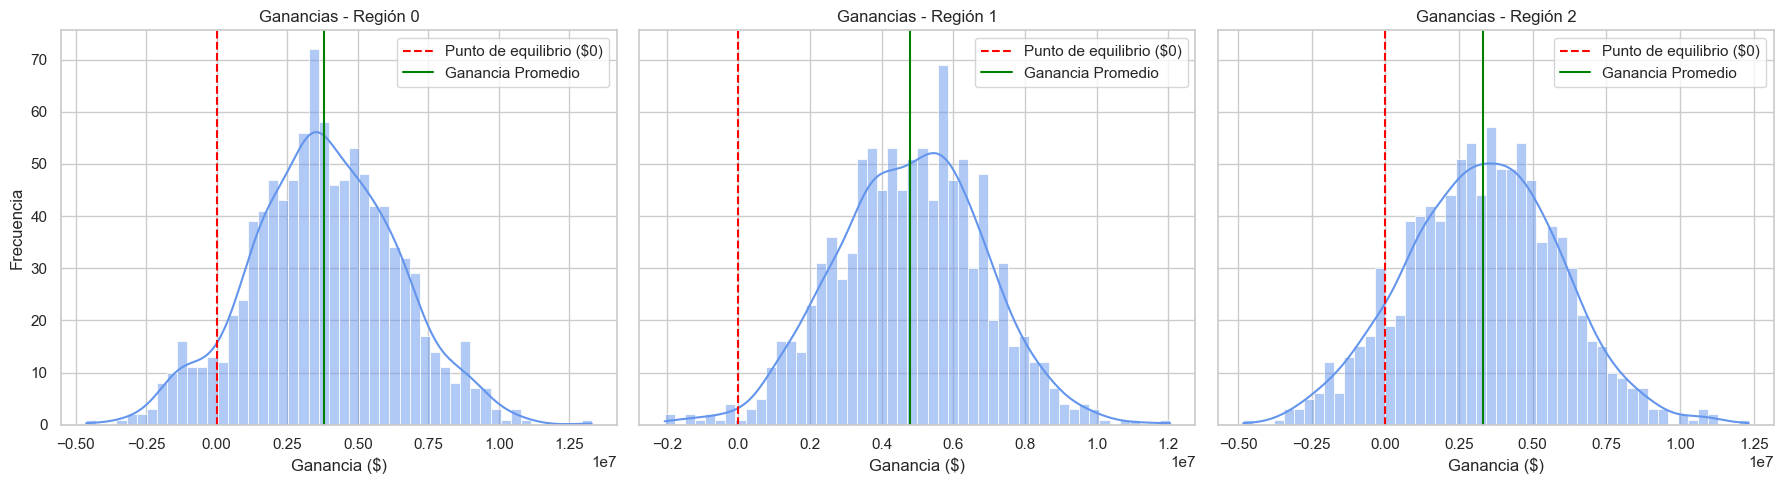

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
regions_profits = [result_0['profits'], result_1['profits'], result_2['profits']]
region_titles = ['Región 0', 'Región 1', 'Región 2']

for i, profits in enumerate(regions_profits):
    sns.histplot(profits, bins=50, kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].axvline(0, color='red', linestyle='--', label='Punto de equilibrio ($0)')
    axes[i].axvline(profits.mean(), color='green', linestyle='-', label='Ganancia Promedio')
    axes[i].set_title(f'Ganancias - {region_titles[i]}')
    axes[i].set_xlabel('Ganancia ($)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.tight_layout()
plt.show()


Tras analizar las tres regiones mediante regresión lineal y evaluar las ganancias utilizando la técnica de bootstrapping, se observa que no todas las regiones cumplen con el criterio de riesgo establecido.

Solo se consideran viables aquellas regiones cuyo riesgo de pérdida es inferior al 2.5%. Entre ellas, la región seleccionada es la que presenta la mayor ganancia promedio esperada.

Esta decisión se basa no solo en la ganancia potencial, sino también en la estabilidad del modelo y en la minimización del riesgo financiero para la empresa.

Al corregir la simulación de bootstrapping (evaluando submuestras de 500 pozos), observamos valores de riesgo más realistas. Como resultado, la Región 1 es la única que cumple el criterio de viabilidad al tener un riesgo de pérdida menor al 2.5% (1.20%).

In [13]:
# Decisión final basada en el riesgo y ganancia esperada
print("DECISIÓN FINAL")
viable_regions = []
for i, res in enumerate([result_0, result_1, result_2]):
    if res['loss_risk'] < 2.5:
        viable_regions.append((i, res['mean_profit']))

if viable_regions:
    best_region = max(viable_regions, key=lambda x: x[1])
    print(f" Región recomendada: {best_region[0]}")
    print(f" Ganancia esperada: ${best_region[1]:,.2f}")
else:
    print(" Ninguna región cumple el criterio de riesgo < 2.5%")



DECISIÓN FINAL
 Región recomendada: 1
 Ganancia esperada: $4,784,849.40


Con base en los resultados del análisis de riesgo mediante bootstrapping, se seleccionaron únicamente las regiones cuyo riesgo de pérdidas es inferior al 2.5%.

Entre las regiones que cumplen este criterio, se eligió aquella con la mayor ganancia promedio esperada como la opción recomendada para el desarrollo de pozos petrolíferos.

## Conclusiones generales del proyecto

Tras completar el análisis integral para la compañía **OilyGiant**, hemos llegado a las siguientes conclusiones clave:

1. **Análisis de Datos y Modelado (Machine Learning):**
   - Se entrenó un modelo de Regresión Lineal para 3 regiones. A través de la *Prueba de Cordura (Baseline)* confirmamos que nuestro modelo supera ampliamente a las predicciones basadas en simples promedios.
   - La **Región 1** demostró ser la más predecible (RMSE de 0.89), impulsado por una fuerte correlación entre sus características geológicas (`f2`) y el volumen de reservas.

2. **Evaluación Financiera y Riesgo (Bootstrapping):**
   - Se simuló el proceso de exploración evaluando lotes de 500 pozos para seleccionar los 200 más prometedores en 1000 iteraciones.
   - Al aplicar estos parámetros de negocio descubrimos que la **Región 0** y la **Región 2** presentan un riesgo de pérdida del **7.70%** y **11.30%** respectivamente, lo cual excede por mucho el límite de tolerancia del 2.5%.
   - Por el contrario, la **Región 1** demostró ser una inversión sumamente segura, con un riesgo de pérdida de tan solo **1.20%**.

3. **Decisión Final Recomendada:**
   - De acuerdo con los criterios de negocio, **la Región 1 es la única zona viable y recomendada para la perforación.**
   - Operar en esta región asegura una ganancia neta promedio esperada de **$4,784,849.40 USD**, optimizando los recursos de exploración y minimizando drásticamente la exposición financiera a posibles pérdidas.